

El objetivo de este proyecto es explorar la relación entre los recursos
sanitarios y los datos sociodemográficos a nivel de condado en EE.UU.,
y construir un modelo de **regresión lineal** para predecir una variable
de salud a partir del resto de indicadores.

Variable objetivo elegida: heart_disease_mortality_per_100k una de
las variables de salud más representativas y con mayor impacto social.

Pasos del EDA:
1. Carga del conjunto de datos
2. Exploración y limpieza de datos
3. Análisis univariante
4. Análisis multivariante
5. Ingeniería de características
6. Selección de características
7. Modelo de regresión lineal base + Lasso
8. Optimización del modelo


## 00 Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.feature_selection import f_regression, SelectKBest
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)


## Paso 1: Carga del conjunto de datos

In [4]:

# Cargamos el dataset
url = "https://breathecode.herokuapp.com/asset/internal-link?id=733&path=demographic_health_data.csv"
df = pd.read_csv(url)


print(f"Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}")
df.head()


Filas: 3140  |  Columnas: 108


,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


## Paso 2: Exploración y limpieza de datos

### 2.1 Tipos de datos y primeras observaciones


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Columns: 108 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), object(2)
memory usage: 2.6+ MB


In [6]:
# Resumen estadístico de las variables numéricas
df.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
fips,3140.0,30401.64,15150.56,1001.0,18180.50,29178.0,45081.50,56045.00
TOT_POP,3140.0,104189.41,333583.40,88.0,10963.25,25800.5,67913.00,10105518.00
0-9,3140.0,12740.30,41807.30,0.0,1280.50,3057.0,8097.00,1208253.00
0-9 y/o % of total pop,3140.0,11.87,2.12,0.0,10.59,11.8,12.95,25.46
19-Oct,3140.0,13367.98,42284.39,0.0,1374.50,3274.0,8822.25,1239139.00
...,...,...,...,...,...,...,...,...
CKD_prevalence,3140.0,3.45,0.57,1.8,3.10,3.4,3.80,6.20
CKD_Lower 95% CI,3140.0,3.21,0.53,1.7,2.90,3.2,3.50,5.80
CKD_Upper 95% CI,3140.0,3.71,0.61,1.9,3.30,3.7,4.10,6.60
CKD_number,3140.0,2466.23,7730.42,3.0,314.75,718.0,1776.25,237766.00


### 2.2 Análisis de valores nulos

In [8]:
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(2)
reporte_nulos = pd.DataFrame({"Nulos": nulos, "Porcentaje %": pct})
reporte_nulos = reporte_nulos[reporte_nulos["Nulos"] > 0].sort_values("Porcentaje %", ascending=False)

print(f"Columnas con valores nulos: {len(reporte_nulos)} de {df.shape[1]}")
reporte_nulos.head(30)


Columnas con valores nulos: 0 de 108


,Nulos,Porcentaje %


In [11]:
# Eliminamos columnas con más del 40% de nulos — no aportan información fiable
umbral = 40
cols_drop_nulos = reporte_nulos[reporte_nulos["Porcentaje %"] > umbral].index.tolist()
print(f"Columnas eliminadas por exceso de nulos (>{umbral}%): {len(cols_drop_nulos)}")
print(cols_drop_nulos)

df.drop(columns=cols_drop_nulos, inplace=True)
print(f"\nForma tras eliminar columnas: {df.shape}")


Columnas eliminadas por exceso de nulos (>40%): 0
[]

Forma tras eliminar columnas: (3140, 108)


no tenemos nulos.!!!

### 2.3 Duplicados y columnas irrelevantes

In [13]:
print(f"Filas duplicadas: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

# Eliminamos columnas identificadoras que no aportan valor predictivo
id_cols = [c for c in df.columns if 'fips' in c.lower() or 'county' in c.lower() or 'state' in c.lower()]
print(f"Columnas identificadoras eliminadas: {id_cols}")
df.drop(columns=id_cols, errors='ignore', inplace=True)

# Eliminamos columnas no numéricas restantes (si las hay)
df.drop(columns=df.select_dtypes(include='object').columns.tolist(), errors='ignore', inplace=True)

print(f"\nForma final del dataset limpio: {df.shape}")


Filas duplicadas: 0
Columnas identificadoras eliminadas: ['fips', 'Med_HH_Income_Percent_of_State_Total_2018', 'COUNTY_NAME', 'STATE_NAME', 'STATE_FIPS', 'CNTY_FIPS', 'county_pop2018_18 and older']

Forma final del dataset limpio: (3140, 101)


### 2.4 Definición de la variable objetivo

Usamos heart_disease_mortality_per_100k (mortalidad por enfermedad cardíaca
por cada 100 000 habitantes) como variable objetivo, por ser una de las
métricas de salud más relevantes y con mejor cobertura en el dataset.


In [14]:
TARGET = 'heart_disease_mortality_per_100k'

# Verificamos que existe en el dataset
if TARGET in df.columns:
    print(f"Variable objetivo encontrada: '{TARGET}'")
    print(f"   Media: {df[TARGET].mean():.2f}")
    print(f"   Mediana: {df[TARGET].median():.2f}")
    print(f"   Std: {df[TARGET].std():.2f}")
else:
    # Si el nombre exacto varía, buscamos columnas similares
    candidatas = [c for c in df.columns if 'heart' in c.lower() or 'cardiac' in c.lower()]
    print("Columnas candidatas:", candidatas)
    TARGET = candidatas[0]
    print(f"Usando: {TARGET}")


Columnas candidatas: ['Heart disease_prevalence', 'Heart disease_Lower 95% CI', 'Heart disease_Upper 95% CI', 'Heart disease_number']
Usando: Heart disease_prevalence


## Paso 3: Análisis univariante

### 3.1 Variable objetivo


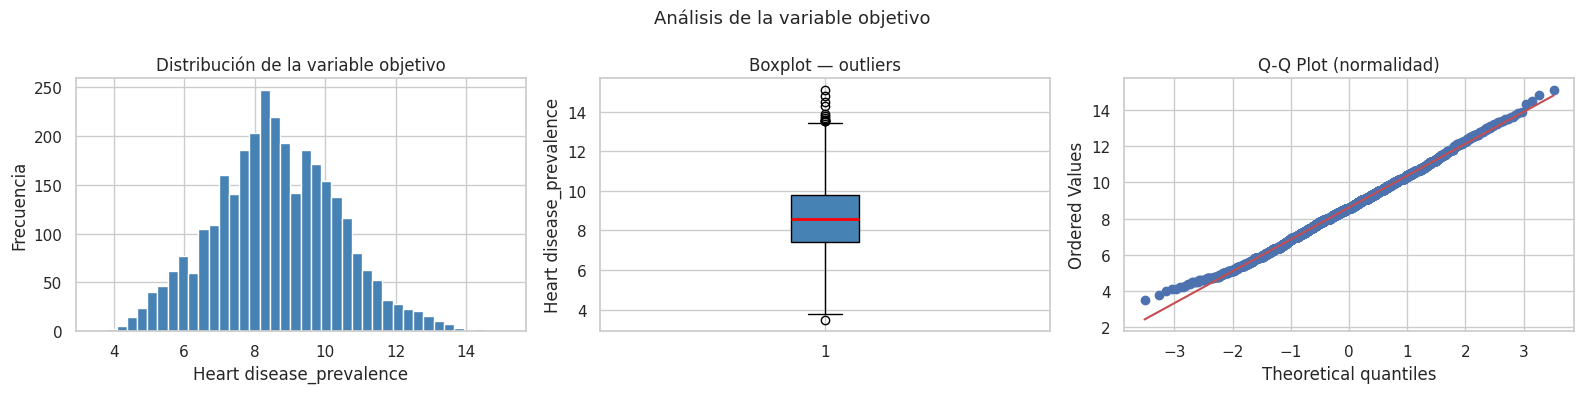

Skewness: 0.114  |  Kurtosis: -0.065


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histograma
axes[0].hist(df[TARGET].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de la variable objetivo')
axes[0].set_xlabel(TARGET)
axes[0].set_ylabel('Frecuencia')

# Boxplot
axes[1].boxplot(df[TARGET].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot — outliers')
axes[1].set_ylabel(TARGET)

# Q-Q plot manual (normalidad)
from scipy import stats
stats.probplot(df[TARGET].dropna(), plot=axes[2])
axes[2].set_title('Q-Q Plot (normalidad)')

plt.suptitle('Análisis de la variable objetivo', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Skewness: {df[TARGET].skew():.3f}  |  Kurtosis: {df[TARGET].kurt():.3f}")


### 3.2 Variables predictoras numéricas

Variables predictoras numéricas: 100


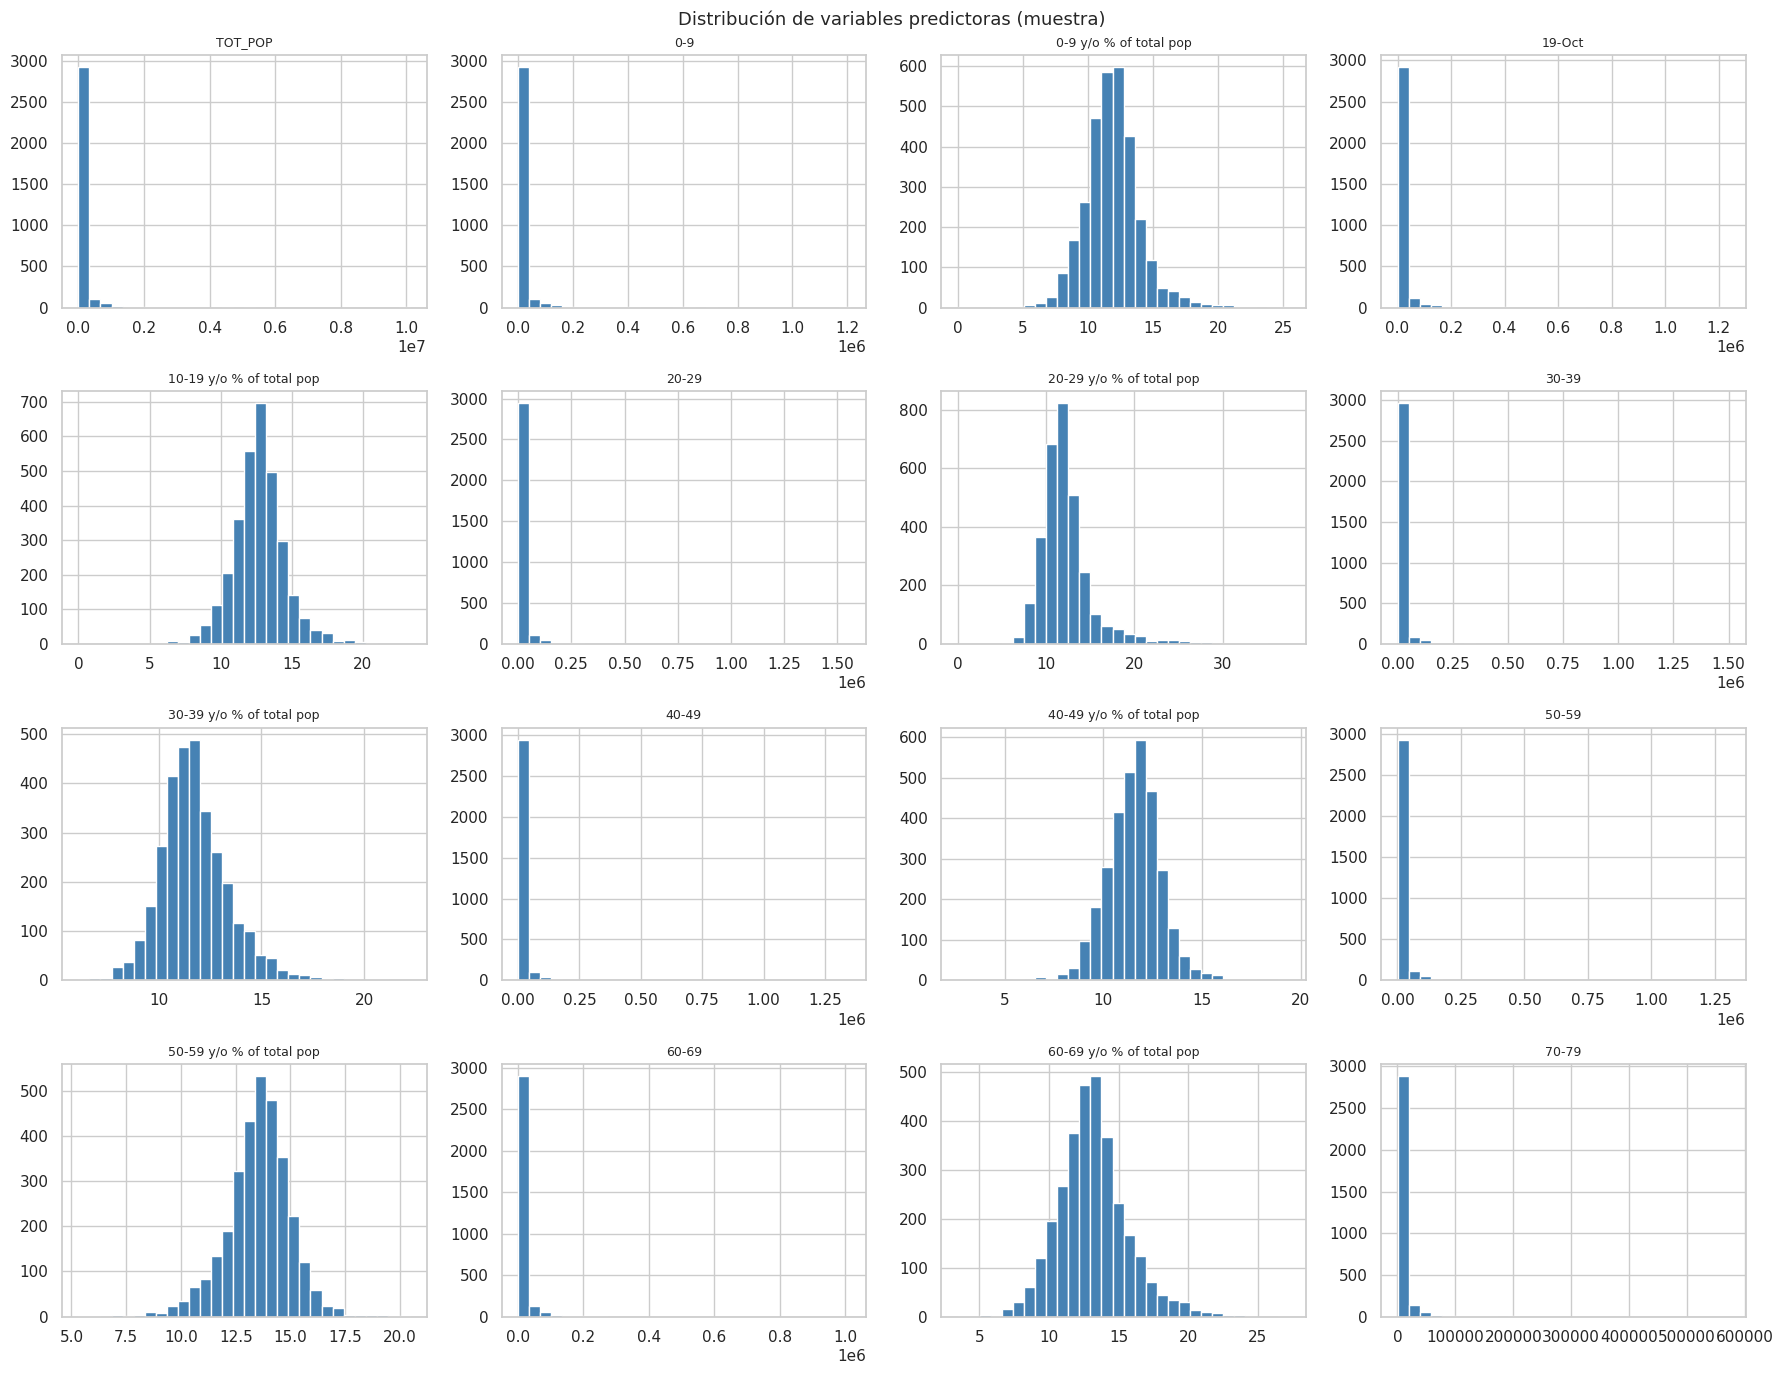

In [18]:
num_cols = [c for c in df.select_dtypes(include='number').columns if c != TARGET]
print(f"Variables predictoras numéricas: {len(num_cols)}")

# Mostramos histogramas de las primeras 16 para no saturar
cols_muestra = num_cols[:16]
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cols_muestra):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=9)

plt.suptitle('Distribución de variables predictoras (muestra)', fontsize=13)
plt.tight_layout()
plt.show()


### 3.3 Detección de outliers

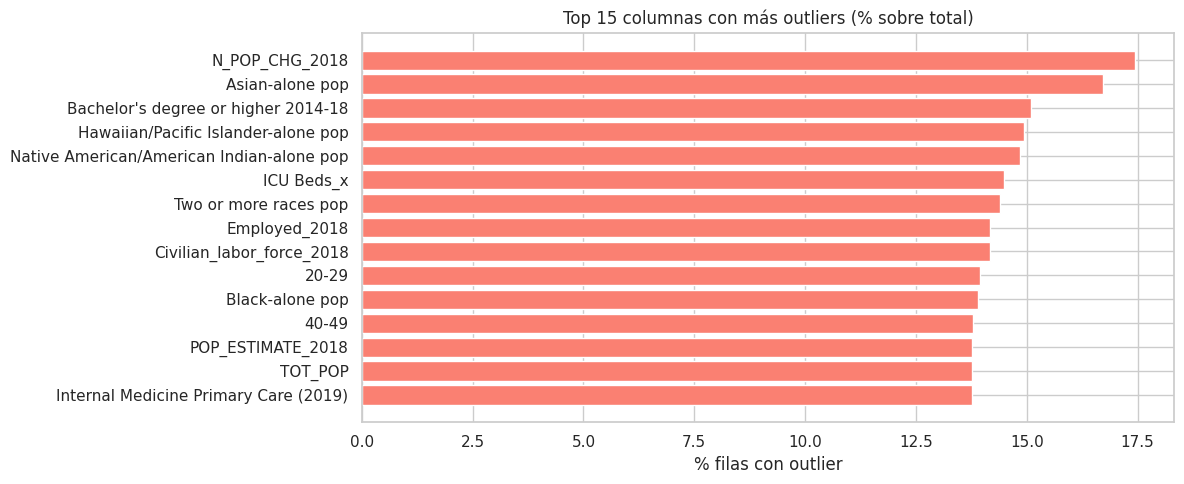

In [19]:
# Contamos outliers por columna (método IQR)
outlier_report = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    outlier_report[col] = n_out

out_df = pd.DataFrame.from_dict(outlier_report, orient='index', columns=['outliers'])
out_df['pct'] = (out_df['outliers'] / len(df) * 100).round(2)
out_df_sorted = out_df.sort_values('pct', ascending=False).head(15)

plt.figure(figsize=(12, 5))
plt.barh(out_df_sorted.index, out_df_sorted['pct'], color='salmon')
plt.xlabel('% filas con outlier')
plt.title('Top 15 columnas con más outliers (% sobre total)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Paso 4: Análisis multivariante

### 4.1 Correlación con la variable objetivo


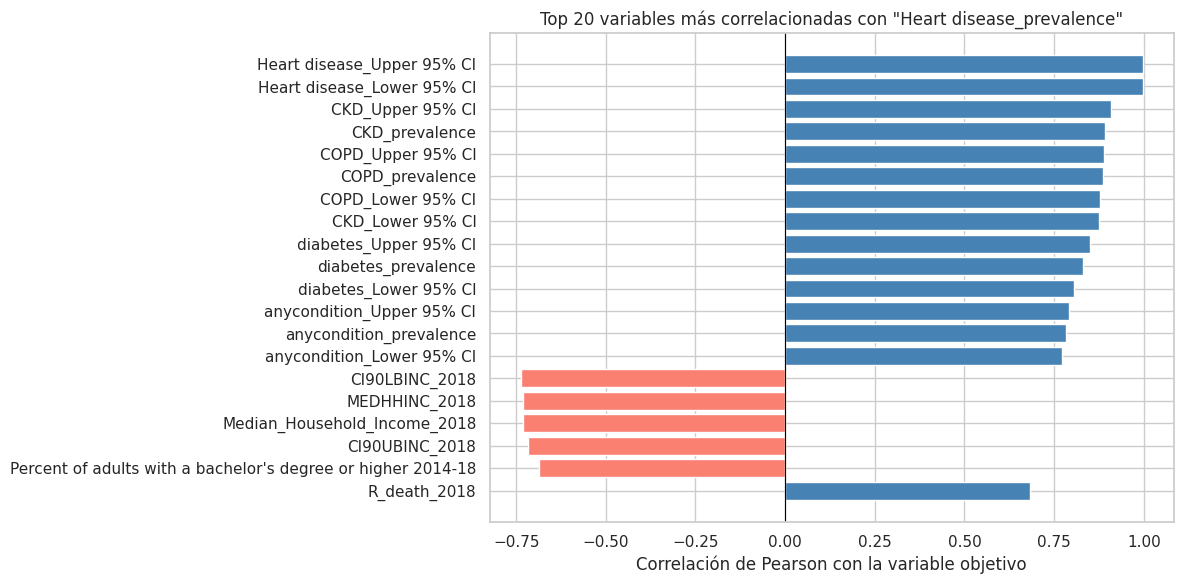


Top 10 correlaciones positivas:
Heart disease_Upper 95% CI    0.998
Heart disease_Lower 95% CI    0.997
CKD_Upper 95% CI              0.908
CKD_prevalence                0.893
COPD_Upper 95% CI             0.890
COPD_prevalence               0.887
COPD_Lower 95% CI             0.878
CKD_Lower 95% CI              0.875
diabetes_Upper 95% CI         0.851
diabetes_prevalence           0.831

Top 10 correlaciones negativas:
Hawaiian/Pacific Islander-alone pop                                      -0.153
% Two or more races                                                      -0.148
R_NET_MIG_2018                                                           -0.118
% NA/AI-alone                                                             0.102
% Black-alone                                                             0.065
R_DOMESTIC_MIG_2018                                                      -0.060
Active Patient Care General Surgeons per 100000 Population 2018 (AAMC)    0.044
% Hawaiian/PI-

In [20]:
corr_target = df[num_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

# Top 20 más correlacionadas
top_corr = corr_target.head(20)
colors = ['steelblue' if v > 0 else 'salmon' for v in top_corr.values]

plt.figure(figsize=(12, 6))
plt.barh(top_corr.index[::-1], top_corr.values[::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Correlación de Pearson con la variable objetivo')
plt.title(f'Top 20 variables más correlacionadas con "{TARGET}"')
plt.tight_layout()
plt.show()

print("\nTop 10 correlaciones positivas:")
print(corr_target.head(10).round(3).to_string())
print("\nTop 10 correlaciones negativas:")
print(corr_target.tail(10).round(3).to_string())


### 4.2 Mapa de correlación entre las top variables

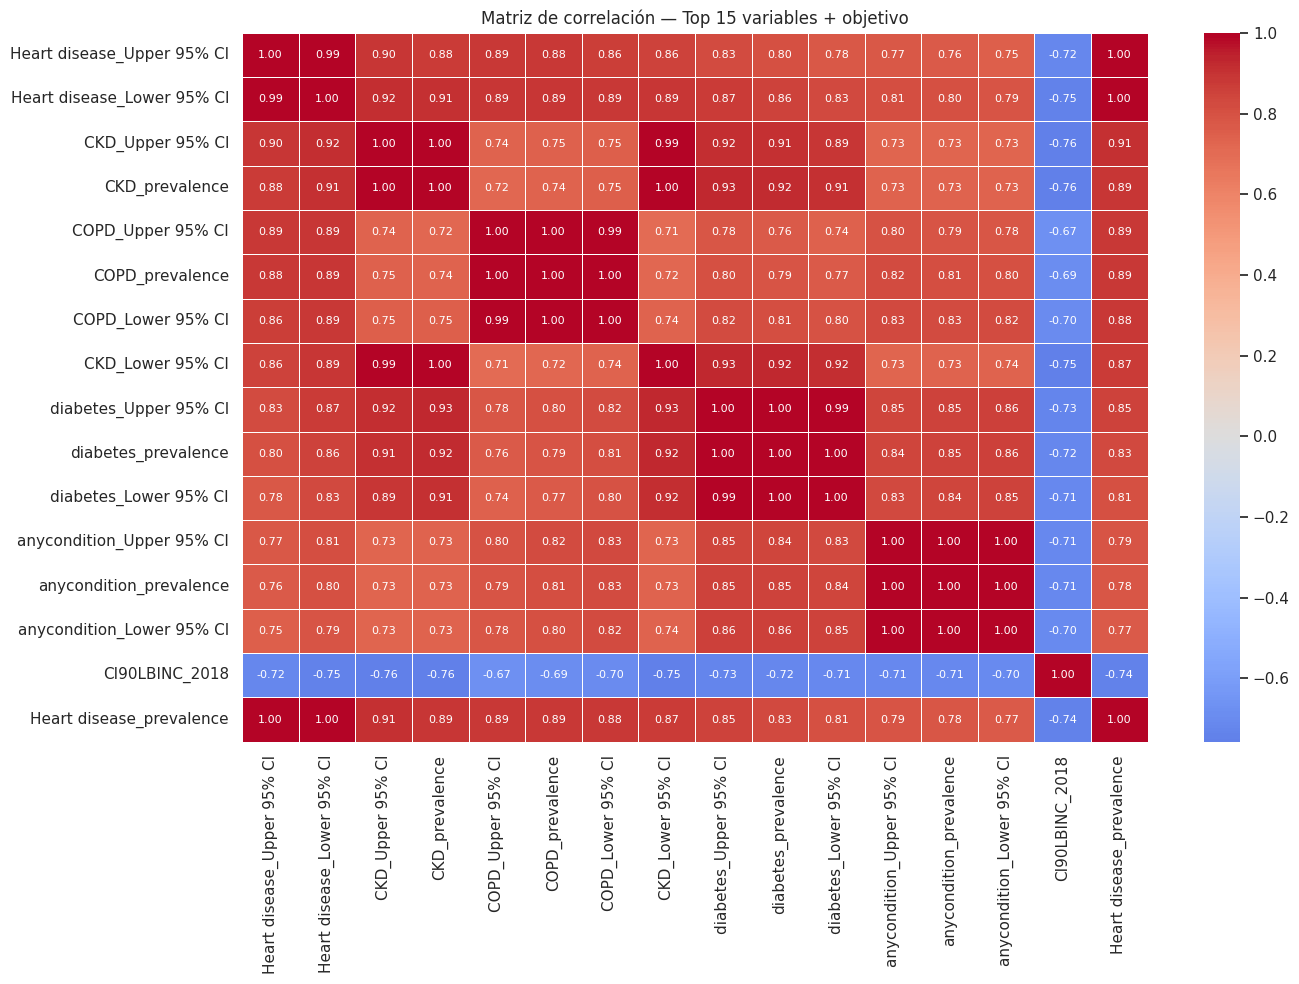

In [ ]:
# Seleccionamos las 15 más correlacionadas con el target + el target
top15_cols = corr_target.abs().head(15).index.tolist() + [TARGET]
corr_matrix = df[top15_cols].corr()

plt.figure(figsize=(14, 10))
#mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # solo cuando queremos medio cuadro  mas mask=mask en sns.heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f",
            cmap='coolwarm', center=0, linewidths=0.5, annot_kws={"size": 8})
plt.title('Matriz de correlación — Top 15 variables + objetivo')
plt.tight_layout()
plt.show()


### 4.3 Scatter plots: predictoras clave vs variable objetivo

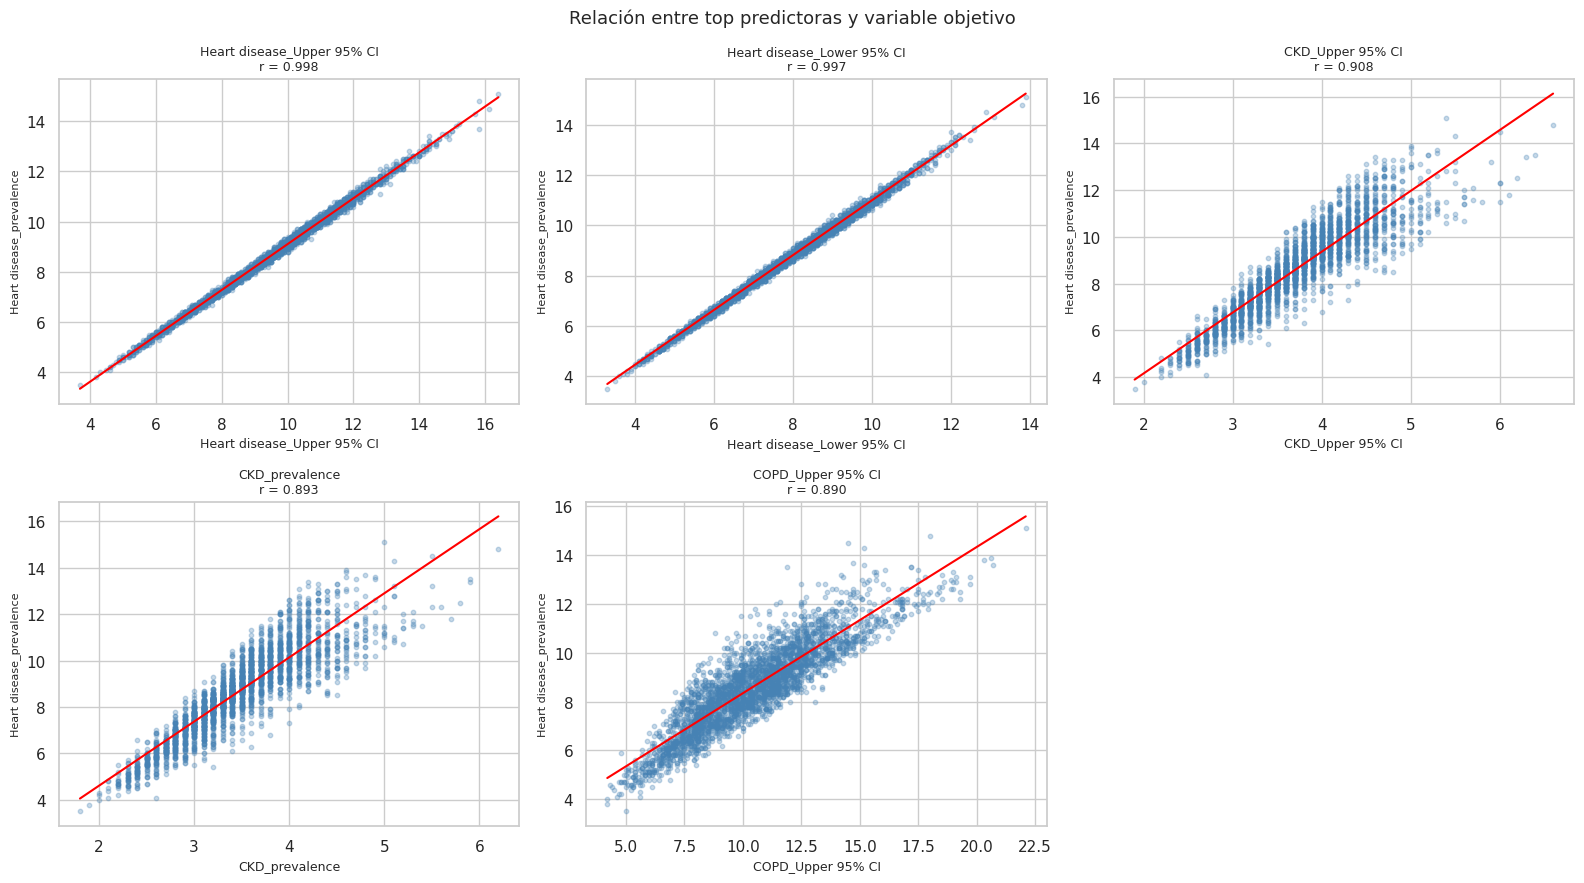

In [24]:
top5 = corr_target.abs().head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(top5):
    axes[i].scatter(df[col], df[TARGET], alpha=0.3, color='steelblue', s=10)
    # Línea de tendencia
    m, b = np.polyfit(df[col].dropna(), df[TARGET][df[col].notna()], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, m*x_line + b, color='red', linewidth=1.5)
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel(TARGET, fontsize=8)
    r = corr_target[col]
    axes[i].set_title(f'{col}\nr = {r:.3f}', fontsize=9)

axes[-1].set_visible(False)
plt.suptitle('Relación entre top predictoras y variable objetivo', fontsize=13)
plt.tight_layout()
plt.show()


## Paso 5: Ingeniería de características

### 5.1 Tratamiento de outliers (clipping IQR)


In [25]:
df_model = df.copy()

# Clipping con IQR en todas las variables numéricas excepto el target
for col in num_cols:
    Q1 = df_model[col].quantile(0.25)
    Q3 = df_model[col].quantile(0.75)
    IQR = Q3 - Q1
    df_model[col] = df_model[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

print("✅ Outliers tratados con clipping IQR en todas las columnas predictoras.")


✅ Outliers tratados con clipping IQR en todas las columnas predictoras.


### 5.2 Eliminación de variables altamente correlacionadas entre sí

In [26]:
# Encontramos pares de predictoras con correlación > 0.92 (multicolinealidad alta)
corr_pred = df_model[num_cols].corr().abs()
upper = corr_pred.where(np.triu(np.ones(corr_pred.shape), k=1).astype(bool))

cols_drop_mc = [col for col in upper.columns if any(upper[col] > 0.92)]
print(f"Columnas eliminadas por multicolinealidad (r > 0.92): {len(cols_drop_mc)}")
print(cols_drop_mc[:10], "..." if len(cols_drop_mc) > 10 else "")

df_model.drop(columns=cols_drop_mc, inplace=True)
num_cols_clean = [c for c in df_model.columns if c != TARGET]
print(f"\nColumnas predictoras restantes: {len(num_cols_clean)}")


Columnas eliminadas por multicolinealidad (r > 0.92): 57
['0-9', '19-Oct', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+', 'White-alone pop'] ...

Columnas predictoras restantes: 43


### 5.3 Escalado de características

In [30]:
# El escalado 
scaler = StandardScaler()

X_raw = df_model[num_cols_clean]
y_raw = df_model[TARGET]

# Primero dividimos, luego escalamos (para evitar data leakage)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_raw),
    columns=num_cols_clean
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_raw),
    columns=num_cols_clean
)

print(f"X_train: {X_train_scaled.shape}  |  X_test: {X_test_scaled.shape}")
print(f"y_train — media: {y_train.mean():.2f}  |  y_test — media: {y_test.mean():.2f}")


X_train: (2512, 43)  |  X_test: (628, 43)
y_train — media: 8.59  |  y_test — media: 8.69


## Paso 6: Selección de características con SelectKBest (F-regression)


In [31]:
# Seleccionamos las K mejores características usando el test F para regresión
K_BEST = 15
selector = SelectKBest(f_regression, k=K_BEST)
selector.fit(X_train_scaled, y_train)

ix = selector.get_support()
X_train_sel = pd.DataFrame(selector.transform(X_train_scaled), columns=X_train_scaled.columns[ix])
X_test_sel  = pd.DataFrame(selector.transform(X_test_scaled),  columns=X_test_scaled.columns[ix])

# Puntuaciones
scores_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'score': selector.scores_,
    'selected': ix
}).sort_values('score', ascending=False)

print("Características seleccionadas:\n")
print(scores_df[scores_df['selected']].to_string(index=False))


Características seleccionadas:

                                                     feature         score  selected
                                  Heart disease_Lower 95% CI 428041.174500      True
                                             COPD_prevalence   9190.133941      True
                                         diabetes_prevalence   5729.022098      True
                                     anycondition_prevalence   4091.431365      True
                                               MEDHHINC_2018   3340.214267      True
                                                R_death_2018   2413.597701      True
Percent of adults with a bachelor's degree or higher 2014-18   2348.389288      True
                                    70-79 y/o % of total pop   1885.290823      True
                                               % Asian-alone   1606.663060      True
   Percent of adults with a high school diploma only 2014-18   1495.136878      True
                                 

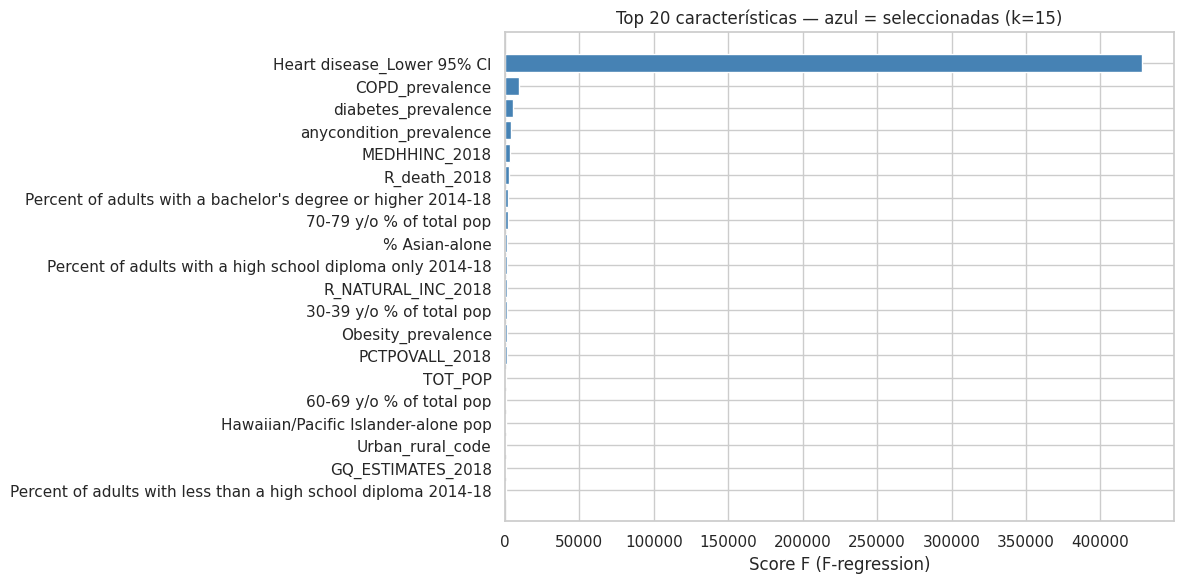

In [32]:
# Visualizamos
top20 = scores_df.head(20)
colors = ['steelblue' if s else 'lightgray' for s in top20['selected']]

plt.figure(figsize=(12, 6))
plt.barh(top20['feature'][::-1], top20['score'][::-1], color=colors[::-1])
plt.xlabel('Score F (F-regression)')
plt.title(f'Top 20 características — azul = seleccionadas (k={K_BEST})')
plt.tight_layout()
plt.show()


## Paso 7: Modelos de regresión

### 7.1 Regresión lineal base


In [33]:
# ── Regresión Lineal ──────────────────────────────────────────────────────────
lin_reg = LinearRegression()
lin_reg.fit(X_train_sel, y_train)

y_pred_lin = lin_reg.predict(X_test_sel)

rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
mae_lin  = mean_absolute_error(y_test, y_pred_lin)
r2_lin   = r2_score(y_test, y_pred_lin)

print("=" * 50)
print("RESULTADOS — Regresión Lineal Base")
print("=" * 50)
print(f"  R²   : {r2_lin:.4f}")
print(f"  RMSE : {rmse_lin:.2f}")
print(f"  MAE  : {mae_lin:.2f}")


RESULTADOS — Regresión Lineal Base
  R²   : 0.9973
  RMSE : 0.09
  MAE  : 0.07


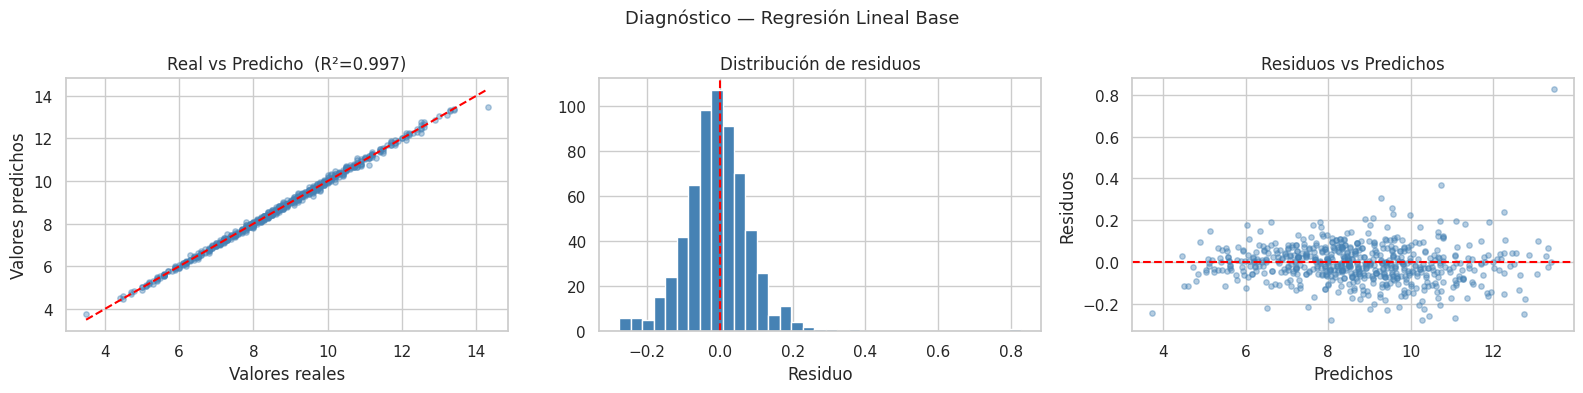

In [34]:
# Residuos del modelo lineal
residuos_lin = y_test - y_pred_lin

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Real vs predicho
axes[0].scatter(y_test, y_pred_lin, alpha=0.4, color='steelblue', s=15)
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], color='red', lw=1.5, linestyle='--')
axes[0].set_xlabel('Valores reales')
axes[0].set_ylabel('Valores predichos')
axes[0].set_title(f'Real vs Predicho  (R²={r2_lin:.3f})')

# Histograma de residuos
axes[1].hist(residuos_lin, bins=35, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Distribución de residuos')
axes[1].set_xlabel('Residuo')

# Residuos vs predichos
axes[2].scatter(y_pred_lin, residuos_lin, alpha=0.4, color='steelblue', s=15)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Predichos')
axes[2].set_ylabel('Residuos')
axes[2].set_title('Residuos vs Predichos')

plt.suptitle('Diagnóstico — Regresión Lineal Base', fontsize=13)
plt.tight_layout()
plt.show()


### 7.2 Modelo Lasso (parámetros por defecto)

In [35]:
# ── Lasso con alpha por defecto (alpha=1.0) ───────────────────────────────────
lasso_base = Lasso(alpha=1.0, max_iter=10000, random_state=42)
lasso_base.fit(X_train_sel, y_train)

y_pred_lasso = lasso_base.predict(X_test_sel)

rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso  = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso   = r2_score(y_test, y_pred_lasso)

print("=" * 50)
print("RESULTADOS — Lasso Base (alpha=1.0)")
print("=" * 50)
print(f"  R²   : {r2_lasso:.4f}")
print(f"  RMSE : {rmse_lasso:.2f}")
print(f"  MAE  : {mae_lasso:.2f}")

# Coeficientes del Lasso (algunos serán exactamente 0)
coef_lasso = pd.DataFrame({
    'feature': X_train_sel.columns,
    'coef': lasso_base.coef_
}).sort_values('coef', key=abs, ascending=False)

print(f"\nVariables eliminadas por Lasso (coef=0): {(coef_lasso['coef']==0).sum()}")
print(coef_lasso.to_string(index=False))


RESULTADOS — Lasso Base (alpha=1.0)
  R²   : 0.6674
  RMSE : 1.04
  MAE  : 0.81

Variables eliminadas por Lasso (coef=0): 14
                                                     feature      coef
                                  Heart disease_Lower 95% CI  0.742938
                                    30-39 y/o % of total pop -0.000000
                                                     TOT_POP -0.000000
                                               % Asian-alone -0.000000
                                                R_death_2018  0.000000
                                          R_NATURAL_INC_2018 -0.000000
                                    70-79 y/o % of total pop  0.000000
   Percent of adults with a high school diploma only 2014-18  0.000000
Percent of adults with a bachelor's degree or higher 2014-18 -0.000000
                                               MEDHHINC_2018 -0.000000
                                              PCTPOVALL_2018  0.000000
                       

### 7.3 Comparativa: Lineal vs Lasso

           Modelo     R²  RMSE  MAE
 Regresión Lineal 0.9973  0.09 0.07
Lasso (alpha=1.0) 0.6674  1.04 0.81


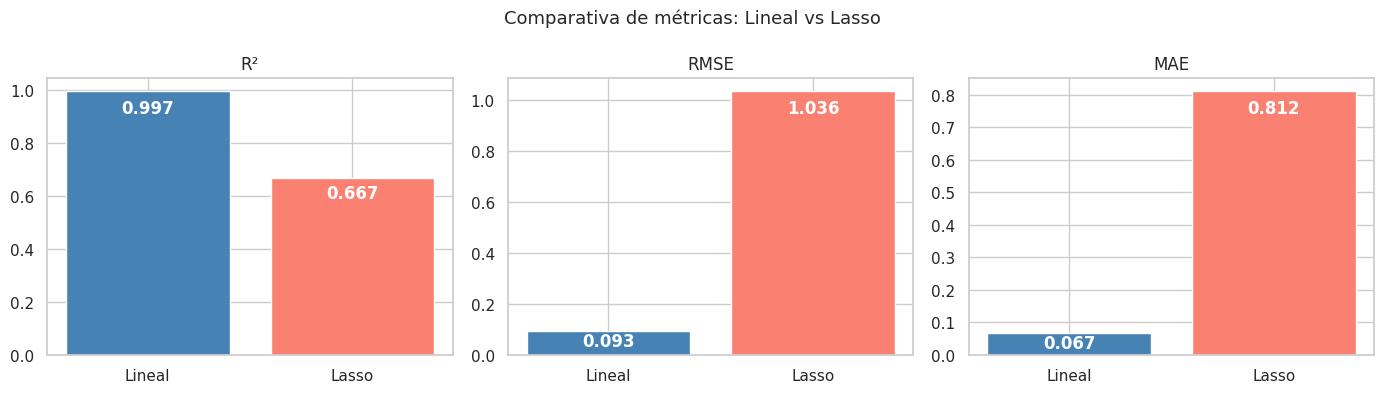

In [36]:
comparativa = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Lasso (alpha=1.0)'],
    'R²':    [round(r2_lin, 4), round(r2_lasso, 4)],
    'RMSE':  [round(rmse_lin, 2), round(rmse_lasso, 2)],
    'MAE':   [round(mae_lin, 2), round(mae_lasso, 2)]
})
print(comparativa.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metricas = ['R²', 'RMSE', 'MAE']
valores  = [[r2_lin, r2_lasso], [rmse_lin, rmse_lasso], [mae_lin, mae_lasso]]
colores  = [['steelblue', 'salmon']] * 3

for i, (met, vals) in enumerate(zip(metricas, valores)):
    axes[i].bar(['Lineal', 'Lasso'], vals, color=['steelblue', 'salmon'])
    axes[i].set_title(met)
    for j, v in enumerate(vals):
        axes[i].text(j, v * 0.97, f'{v:.3f}', ha='center', va='top',
                     color='white', fontweight='bold')

plt.suptitle('Comparativa de métricas: Lineal vs Lasso', fontsize=13)
plt.tight_layout()
plt.show()


### 7.4 Evolución del R² con diferentes valores de alpha (Lasso)

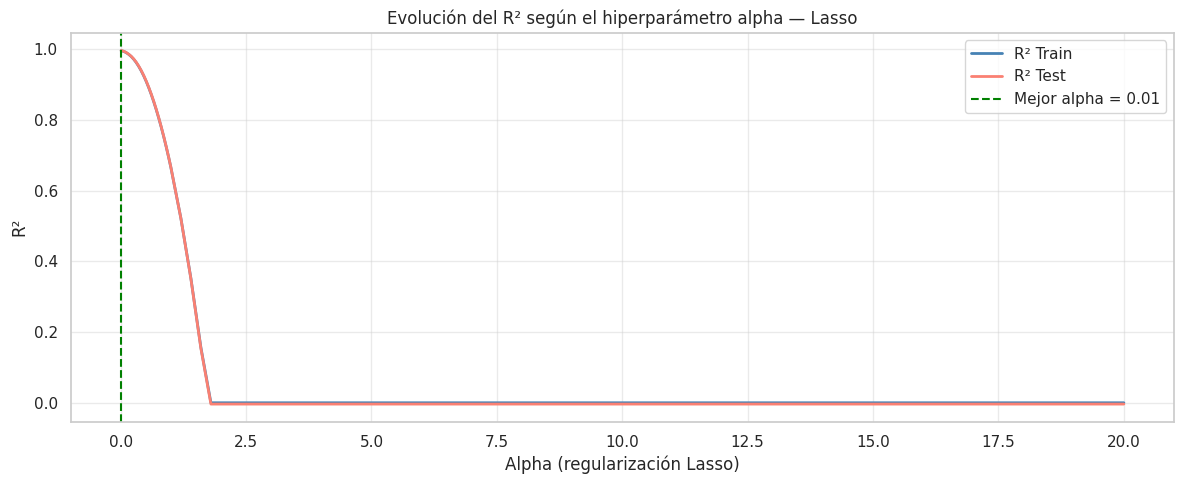

✅ Mejor alpha: 0.0100  →  R² Test: 0.9966


In [37]:
alphas = np.concatenate([
    np.arange(0.01, 1.0, 0.05),
    np.arange(1.0, 5.0, 0.2),
    np.arange(5.0, 20.1, 0.5)
])

r2_train_list = []
r2_test_list  = []

for a in alphas:
    model = Lasso(alpha=a, max_iter=10000, random_state=42)
    model.fit(X_train_sel, y_train)
    r2_train_list.append(r2_score(y_train, model.predict(X_train_sel)))
    r2_test_list.append(r2_score(y_test,  model.predict(X_test_sel)))

plt.figure(figsize=(12, 5))
plt.plot(alphas, r2_train_list, label='R² Train', color='steelblue', linewidth=2)
plt.plot(alphas, r2_test_list,  label='R² Test',  color='salmon',    linewidth=2)
plt.axvline(alphas[np.argmax(r2_test_list)], color='green',
            linestyle='--', label=f'Mejor alpha = {alphas[np.argmax(r2_test_list)]:.2f}')
plt.xlabel('Alpha (regularización Lasso)')
plt.ylabel('R²')
plt.title('Evolución del R² según el hiperparámetro alpha — Lasso')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

best_alpha = alphas[np.argmax(r2_test_list)]
best_r2    = max(r2_test_list)
print(f"✅ Mejor alpha: {best_alpha:.4f}  →  R² Test: {best_r2:.4f}")


## Paso 8: Optimización del modelo

### 8.1 Lasso con el alpha óptimo encontrado


In [38]:
lasso_opt = Lasso(alpha=best_alpha, max_iter=10000, random_state=42)
lasso_opt.fit(X_train_sel, y_train)

y_pred_opt = lasso_opt.predict(X_test_sel)

rmse_opt = np.sqrt(mean_squared_error(y_test, y_pred_opt))
mae_opt  = mean_absolute_error(y_test, y_pred_opt)
r2_opt   = r2_score(y_test, y_pred_opt)

print("=" * 55)
print(f"RESULTADOS — Lasso Optimizado (alpha={best_alpha:.4f})")
print("=" * 55)
print(f"  R²   : {r2_opt:.4f}")
print(f"  RMSE : {rmse_opt:.2f}")
print(f"  MAE  : {mae_opt:.2f}")


RESULTADOS — Lasso Optimizado (alpha=0.0100)
  R²   : 0.9966
  RMSE : 0.11
  MAE  : 0.08


### 8.2 Diagnóstico del modelo optimizado

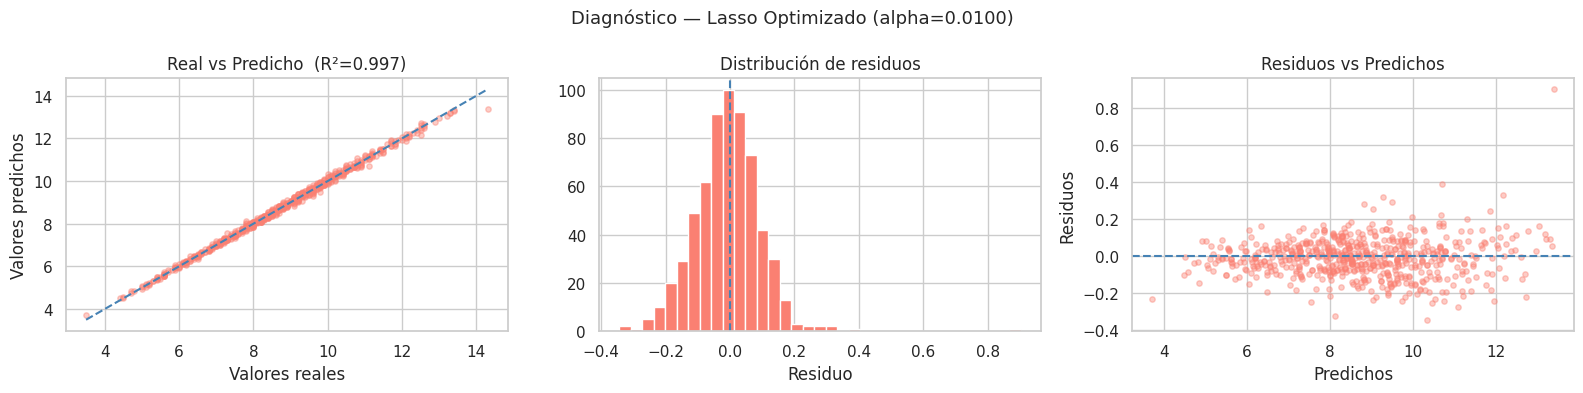

In [39]:
residuos_opt = y_test - y_pred_opt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Real vs predicho
mn, mx = y_test.min(), y_test.max()
axes[0].scatter(y_test, y_pred_opt, alpha=0.4, color='salmon', s=15)
axes[0].plot([mn, mx], [mn, mx], color='steelblue', lw=1.5, linestyle='--')
axes[0].set_xlabel('Valores reales')
axes[0].set_ylabel('Valores predichos')
axes[0].set_title(f'Real vs Predicho  (R²={r2_opt:.3f})')

# Histograma de residuos
axes[1].hist(residuos_opt, bins=35, color='salmon', edgecolor='white')
axes[1].axvline(0, color='steelblue', linestyle='--')
axes[1].set_title('Distribución de residuos')
axes[1].set_xlabel('Residuo')

# Residuos vs predichos
axes[2].scatter(y_pred_opt, residuos_opt, alpha=0.4, color='salmon', s=15)
axes[2].axhline(0, color='steelblue', linestyle='--')
axes[2].set_xlabel('Predichos')
axes[2].set_ylabel('Residuos')
axes[2].set_title('Residuos vs Predichos')

plt.suptitle(f'Diagnóstico — Lasso Optimizado (alpha={best_alpha:.4f})', fontsize=13)
plt.tight_layout()
plt.show()


### 8.3 Resumen final de todos los modelos

                     Modelo     R²  RMSE  MAE
           Regresión Lineal 0.9973  0.09 0.07
          Lasso (alpha=1.0) 0.6674  1.04 0.81
Lasso Óptimo (alpha=0.0100) 0.9966  0.11 0.08


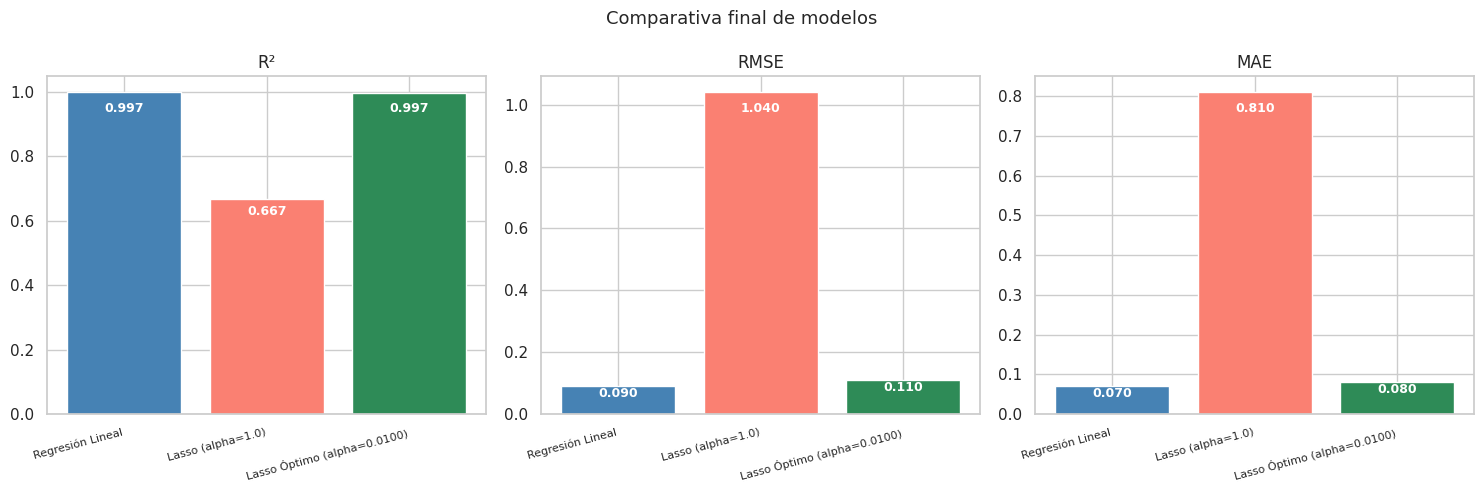

In [40]:
resumen = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Lasso (alpha=1.0)', f'Lasso Óptimo (alpha={best_alpha:.4f})'],
    'R²':    [round(r2_lin, 4),   round(r2_lasso, 4),  round(r2_opt, 4)],
    'RMSE':  [round(rmse_lin, 2), round(rmse_lasso, 2), round(rmse_opt, 2)],
    'MAE':   [round(mae_lin, 2),  round(mae_lasso, 2),  round(mae_opt, 2)]
})
print(resumen.to_string(index=False))

# Gráfico de barras agrupadas
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
modelos = resumen['Modelo'].tolist()
colores = ['steelblue', 'salmon', 'seagreen']

for i, (met, col) in enumerate(zip(['R²', 'RMSE', 'MAE'], ['R²', 'RMSE', 'MAE'])):
    vals = resumen[met].tolist()
    bars = axes[i].bar(modelos, vals, color=colores)
    axes[i].set_title(met)
    axes[i].set_xticklabels(modelos, rotation=15, ha='right', fontsize=8)
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 0.97,
                     f'{v:.3f}', ha='center', va='top', color='white', fontweight='bold', fontsize=9)

plt.suptitle('Comparativa final de modelos', fontsize=13)
plt.tight_layout()
plt.show()


### 8.4 Conclusiones


- La Regresión Lineal, establece el punto de referencia, pero puede  sufrir sobreajuste si hay muchas variables predictoras correlacionadas.
- El Lasso introduce regularización L1 que lleva los coeficientes de   variables poco relevantes exactamente a cero, actuando como selector
  automático de características
- Al ajustar el alpha óptimo encontramos el equilibrio entre sesgo y
  varianza: demasiado alpha → el modelo se vuelve demasiado simple (underfitting);
  demasiado poco → se comporta casi como la regresión lineal sin regularización.
- Las variables más relacionadas con la mortalidad cardíaca por condado tienden
  a ser indicadores socioeconómicos (pobreza, desempleo) y de acceso a la
  salud (médicos por habitante, hospitales), lo que confirma la hipótesis
  del proyecto.

